# Выбор локации для скважины. Обзор данных и EDA.

Добывающей компании «ГлавРосГосНефть» нужно решить, где бурить новую скважину.
Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

По условиям задачи для обучения модели подходит только линейная регрессия.

## Содержание
* [Загрузка и обзор данных](#rew)
* [Исследовательский анализ](#eda)
* * [Первый регион](#first)
* * [Второй регион](#sec)
* * [Третий регион](#third)
* [Вывод](#end)

## Загрузка и обзор данных <a id="rew"></a>

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
sys.path.append(os.path.abspath(os.path.join('..')))
from scr.utils import review_data, plot_distribution, plot_matrix, plot_pairplot

RANDOM_STATE = 228
TEST_SIZE = 0.25

Загрузим данные о скважинах в трёх регионах

In [2]:
names = ['geo_data_0', 'geo_data_1', 'geo_data_2']

df0, df1, df2 = [pd.read_csv(f'../data/{name}.csv') for name in names]

**Первый регион - geo_data_0.csv:**

In [3]:
df0.sample(5, random_state=RANDOM_STATE)

,id,f0,f1,f2,product
80393,xAXdt,0.563640,-0.518544,3.757343,120.230779
90479,j87le,0.182846,-0.201099,3.538456,86.735711
96406,RDWTD,-0.996702,-0.134295,-1.408798,61.911835
6909,n1RB8,0.243061,-0.043067,-2.366682,101.620617
48361,8ADqA,1.127978,-0.532692,2.420674,116.438687


Каждый датасет содержит id скважены, четыре вещественных признака - f0, f1, f2 и целевой product - объем запаса скважены.

Проверим данные на пропуски, дубликаты и соответствие типов данных.

In [4]:
review_data(df0);

📂 Размерность: 100,000 строк × 5 столбцов

✅ Пропусков нет

🔄 Явные дубликаты: 0

🔍 Типы данных и уникальные значения:
• id                        | тип: str      | уник: 99,990 | пропуски:   0.0%
• f0                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f1                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f2                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• product                   | тип: float64  | уник: 100,000 | пропуски:   0.0%



В первой таблице 100 тысяч строк, пропуски и дубликаты отсутствуют. Типы данных в столбцах верные, id - string, остальные имеют вещественный тип данных.

В столбце id меньше уникальных значений, значит есть повторяющиеся идентификаторы, проверим

In [5]:
df0[df0.duplicated(subset=['id'], keep=False)].sort_values(by='id')[:6]

,id,f0,f1,f2,product
66136,74z30,1.084962,-0.312358,6.990771,127.643327
64022,74z30,0.741456,0.459229,5.153109,140.771492
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504


id повторяется, но данные разные, так как cтолбец id всё равно не понадобится, мы проигнорируем эти повторения.

**Второй регион - geo_data_1.csv:**

In [6]:
df1.sample(5, random_state=RANDOM_STATE)

,id,f0,f1,f2,product
80393,1STPV,25.773783,0.318702,4.990121,134.766305
90479,L0h7u,5.206126,-4.468407,5.006644,134.766305
96406,Lnh0V,5.520082,-11.451360,2.996036,80.859783
6909,5EIhB,3.296669,-9.513019,4.998473,137.945408
48361,xxJAa,13.276659,-0.929578,1.993914,53.906522


In [7]:
review_data(df1);

📂 Размерность: 100,000 строк × 5 столбцов

✅ Пропусков нет

🔄 Явные дубликаты: 0

🔍 Типы данных и уникальные значения:
• id                        | тип: str      | уник: 99,996 | пропуски:   0.0%
• f0                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f1                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f2                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• product                   | тип: float64  | уник:    12 | пропуски:   0.0%



В отличие от первой таблицы целевой признак имеет всего 12 уникальных значения, учитывая тип float сложно поверить в повторение объема у такого количества скважен - это ошибка, возможно, в записи или выгрузке данных. Других аномалий и ошибок нет.

**Третий регион - geo_data_2.csv:**

In [8]:
df2.sample(5, random_state=RANDOM_STATE)

,id,f0,f1,f2,product
80393,05j2r,-2.329898,-3.303510,3.504589,173.734556
90479,fvROv,-0.263862,2.504527,-0.035571,84.666547
96406,t4up9,-1.486484,-3.976421,-0.900718,70.636319
6909,0bXYL,0.962695,-0.020751,-2.810286,79.903068
48361,kDgbe,0.209615,-1.173029,6.881180,157.663891


In [9]:
review_data(df2);

📂 Размерность: 100,000 строк × 5 столбцов

✅ Пропусков нет

🔄 Явные дубликаты: 0

🔍 Типы данных и уникальные значения:
• id                        | тип: str      | уник: 99,996 | пропуски:   0.0%
• f0                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f1                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• f2                        | тип: float64  | уник: 100,000 | пропуски:   0.0%
• product                   | тип: float64  | уник: 100,000 | пропуски:   0.0%



Таблица с данными о третьем регионе, также не имеет ошибок в типах, пропусков или дубликатов. Есть повторения id, но product имеет 100 тысяч уникальных значений.

**Итог обзора данных:**
* Во всех трёх данных есть повторения id, но значения признаков отличаются;
* Во втором регионе 12 уникальных значений объёма на 100 тысяч скважен, это аномалия. Обученая на таких данных модель будет непригодня для работы в реальной практике;
* Типы данных во всех таблицах верные, пропусков и явных дубликатов нет.

## Исследовательский анализ <a id="eda"></a>

Исследуем распределение признаков у каждого региона, проведём корреляционный анализ.

### Первый регион <a id="first"></a>

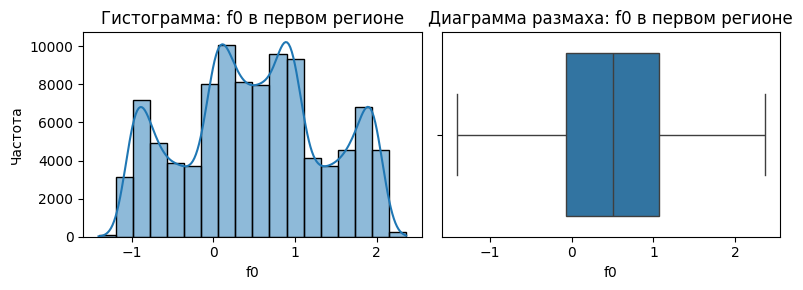


Статистика по f0 в первом регионе:
Среднее: 0.5004 | Медиана: 0.5024
Минимум: -1.4086 | Максимум: 2.3623


In [10]:
plot_distribution(df0, 'f0', 'f0 в первом регионе', figsize=(8, 3))

Распределение данных практически симметричное относительно 0.5, выделяется 4 чётких пика значений, возможно признак содержит значения из разных подвыборок, разброс данных от -1.5 до 2.5. Выбросов нет.

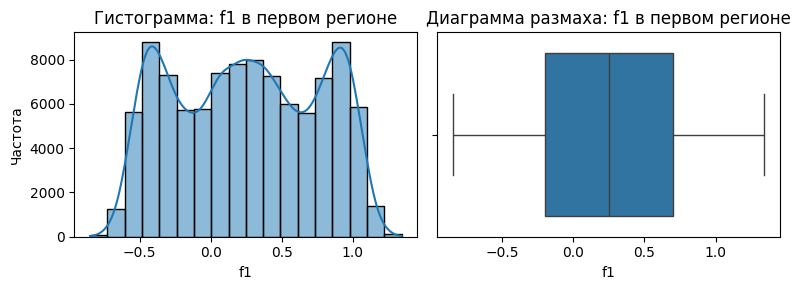


Статистика по f1 в первом регионе:
Среднее: 0.2501 | Медиана: 0.2503
Минимум: -0.8482 | Максимум: 1.3438


In [11]:
plot_distribution(df0, 'f1', 'f1 в первом регионе', figsize=(8, 3))

Выбросов также нет, снова несколько пиков значений, возможно в регионе есть несколько подгрупп с подобными значениями. Можно проверить как зависят друг от друга f0 и f1

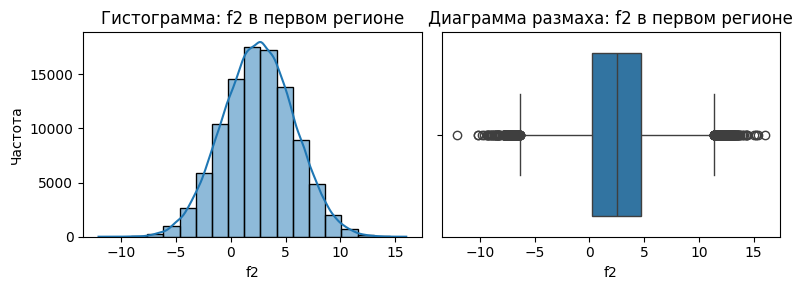


Статистика по f2 в первом регионе:
Среднее: 2.5026 | Медиана: 2.5160
Минимум: -12.0883 | Максимум: 16.0038


In [12]:
plot_distribution(df0, 'f2', 'f2 в первом регионе', figsize=(8, 3))

Расппределение третьего признака отличается, данные распределены нормально относительно пика 2.5, на диаграмме размаха видны выбросы.

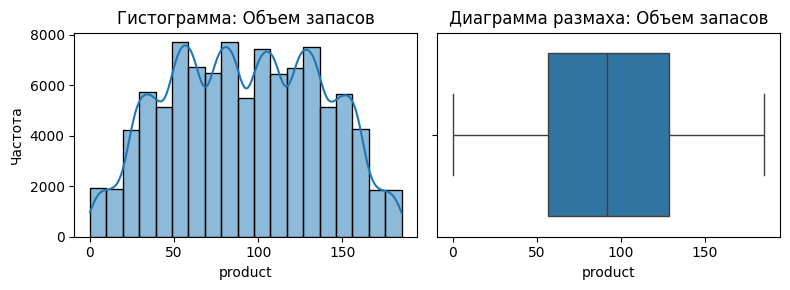


Статистика по Объем запасов:
Среднее: 92.5000 | Медиана: 91.8500
Минимум: 0.0000 | Максимум: 185.3643


In [13]:
plot_distribution(df0, 'product', 'Объем запасов', figsize=(8, 3))

Запасы в первом регионе распределены неравномерно от 0 до 180, есть большое количество точек с примерно одинаковым запасом объема в скважинах.

Проверим корреляцию признаков.

In [14]:
cols = ['f0', 'f1', 'f2', 'product']

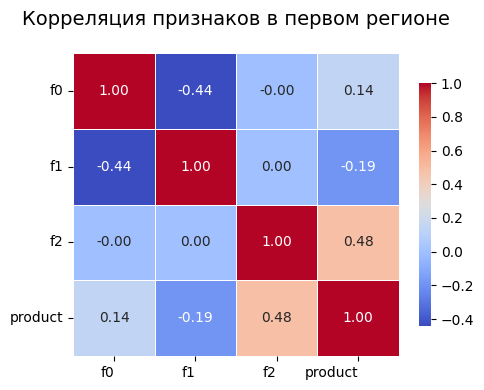

In [15]:
plot_matrix(df0, cols, title='Корреляция признаков в первом регионе', figsize=(5, 4))

Корреляция входных признаков с целевым слабая, f0 и f1 показывают значение 0.14 и -0.19 соответственно, f2 имеет самую сильную корреляцию 0.48

Признаки слабо объясняют целевой, предсказательная способность у модели может быть низкой. Посмотрим как соотносятся друг с другом признаки на диаграмме рассеивания.

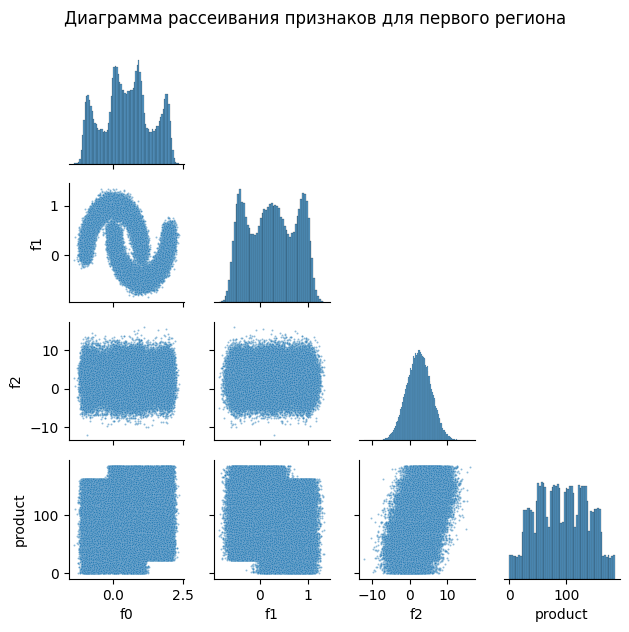

In [16]:
plot_pairplot(df0, title='Диаграмма рассеивания признаков для первого региона')

На диаграмме видно, что f0 и f1 на своём графике образуют две группы значений в дугах, на графике product и f0 также выдны 2 блока значений. Линейная модель не увидит такие закономерности, по этому разделим в данных эти кластеры на 2 метки в отдельный бинарный признак. С такой задачей справится алгоритм DBSCAN.

In [17]:
X = df0[['f0', 'f1']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# алгоритм кластеризации
dbscan = DBSCAN(eps=0.05, min_samples=10)   #лучшие значения после перебора
df0['cluster'] = dbscan.fit_predict(X_scaled)

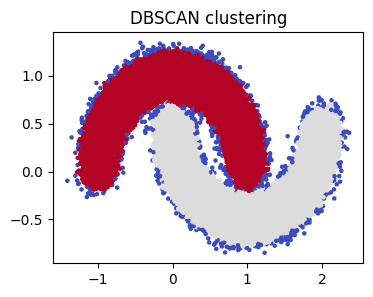

cluster
 1    49732
 0    49698
-1      570
Name: count, dtype: int64
Количество выбросов (-1): 570


In [18]:
# График и подсчёт меток
plt.figure(figsize=(4, 3))
plt.scatter(df0['f0'], df0['f1'], c=df0['cluster'], cmap='coolwarm', s=5)
plt.title('DBSCAN clustering')
plt.show()

print(df0['cluster'].value_counts());
print("Количество выбросов (-1):", (df0['cluster'] == -1).sum())

Алгоритму удалось почти полностью разделить кластеры, остался шум который мы можем объединить с классами методом поиска ближайщих соседей.

In [19]:
mask = df0['cluster'] != -1
X_good = df0.loc[mask, ['f0', 'f1']].values
labels_good = df0.loc[mask, 'cluster'].values

# Обучаем поиск ближайших соседей
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_good)

# Находим ближайший кластер для выбросов
X_noise = df0.loc[~mask, ['f0', 'f1']].values
distances, indices = nn.kneighbors(X_noise)

# Присваиваем метку ближайшей точки
df0.loc[~mask, 'cluster'] = labels_good[indices.flatten()]

Снова посмотрим на диаграмму рассеивания, но уже с помеченными по классам данными.

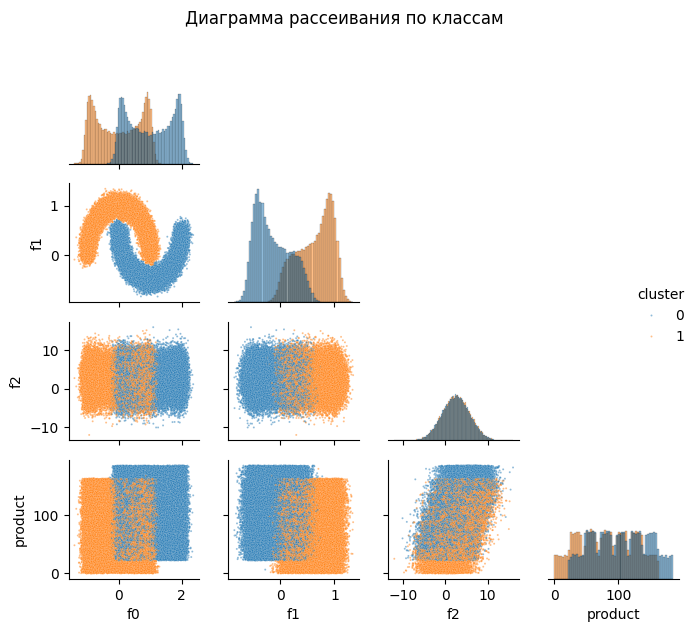

In [20]:
plot_pairplot(df0, hue='cluster', title='Диаграмма рассеивания по классам')

In [21]:
#сохраним чтобы не повторяться
#df0.to_csv('geo_data_0_prep.csv', index=False)

Разделив данные, видно что есть 2 чёткие подгруппы и распределение целевого признака в них различается по f0 и f1, это будет полезно для нашей модели.

### Второй регион <a id="sec"></a>

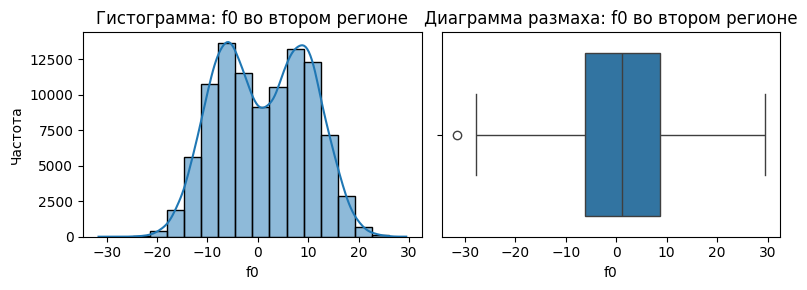


Статистика по f0 во втором регионе:
Среднее: 1.1413 | Медиана: 1.1531
Минимум: -31.6096 | Максимум: 29.4218


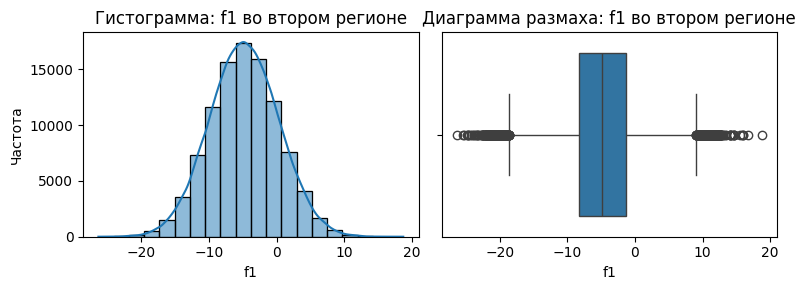


Статистика по f1 во втором регионе:
Среднее: -4.7966 | Медиана: -4.8132
Минимум: -26.3586 | Максимум: 18.7341


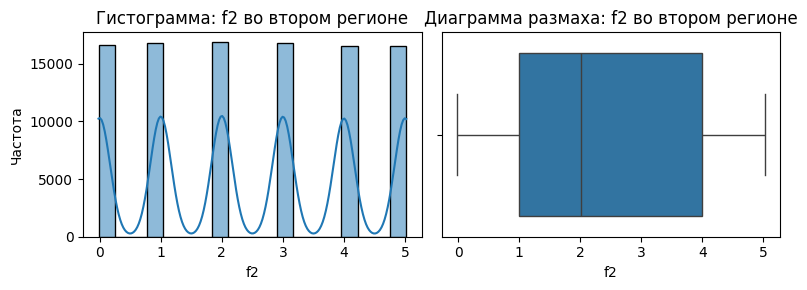


Статистика по f2 во втором регионе:
Среднее: 2.4945 | Медиана: 2.0115
Минимум: -0.0181 | Максимум: 5.0197


In [22]:
for f in ['f0', 'f1', 'f2']:
    plot_distribution(df1, f, f'{f} во втором регионе', figsize=(8, 3))

Первые два признака имеют привычное распределение: у f0 2 пика (возможно снова 2 подвыборки) и диапазон значений от -30 до 30, f1 имеет нормальное распределение.

Признак f2 имеет 6 групп значений, в обзоре данных у признака не было повторяющихся значений, значит данные незачительно отличаются от самого частого в своей группе, проверим распределение целевого признака (у которого 12 уникальных значений) и корреляцию.

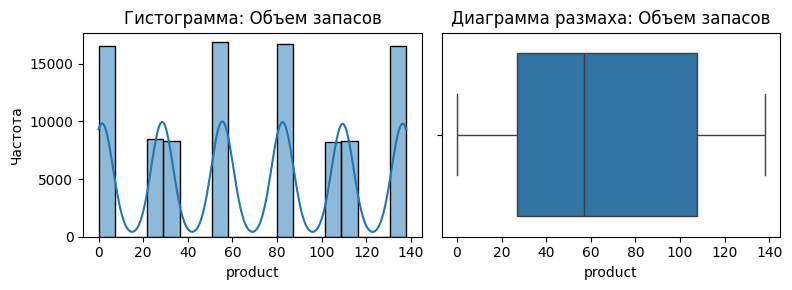


Статистика по Объем запасов:
Среднее: 68.8250 | Медиана: 57.0856
Минимум: 0.0000 | Максимум: 137.9454


In [23]:
plot_distribution(df1, 'product', 'Объем запасов', figsize=(8, 3))

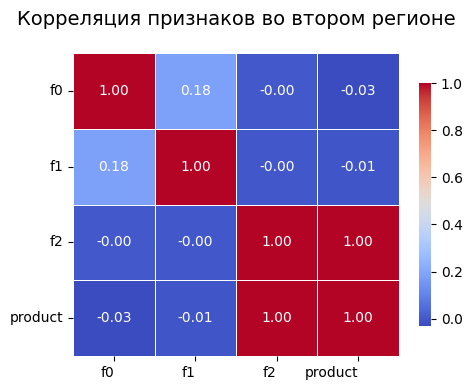

In [24]:
plot_matrix(df1, cols, title='Корреляция признаков во втором регионе', figsize=(5, 4))

12 значений целевого признака складываются в 8 групп на гистогамме и полностью коррелируют со признаком f2, с увеличением значения f2 увеличивается product, остальные признаки показывают нулевую корреляцию.

Обучить модель на таких данных можно, но бессмысленно, так как объем запасов принимает 12 значений и имеет идеальную линейную связь с f2.

### Третий регион<a id="third"></a>

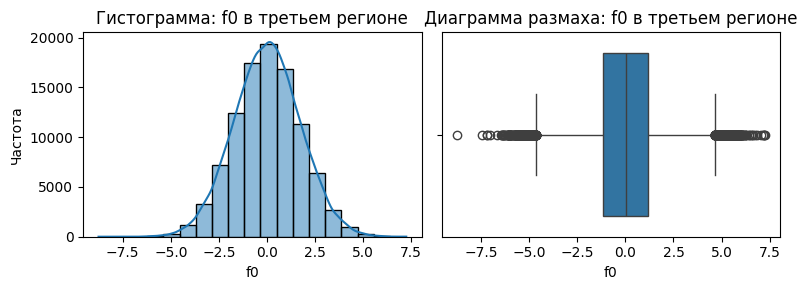


Статистика по f0 в третьем регионе:
Среднее: 0.0020 | Медиана: 0.0094
Минимум: -8.7600 | Максимум: 7.2383


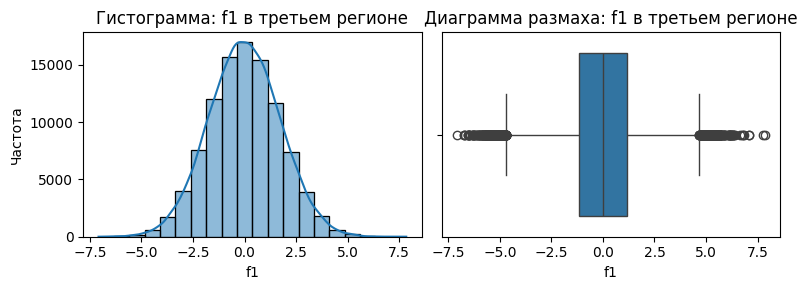


Статистика по f1 в третьем регионе:
Среднее: -0.0021 | Медиана: -0.0095
Минимум: -7.0840 | Максимум: 7.8448


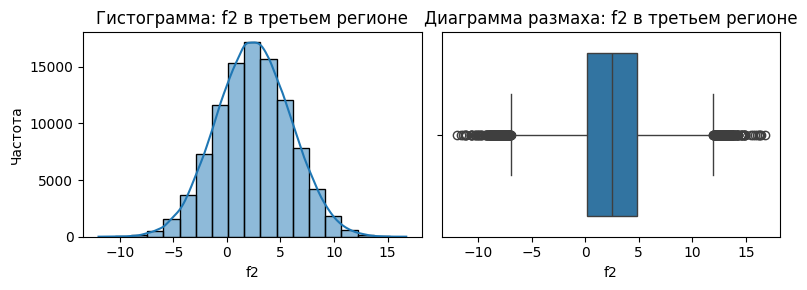


Статистика по f2 в третьем регионе:
Среднее: 2.4951 | Медиана: 2.4842
Минимум: -11.9703 | Максимум: 16.7394


In [25]:
for f in ['f0', 'f1', 'f2']:
    plot_distribution(df2, f, f'{f} в третьем регионе', figsize=(8, 3))

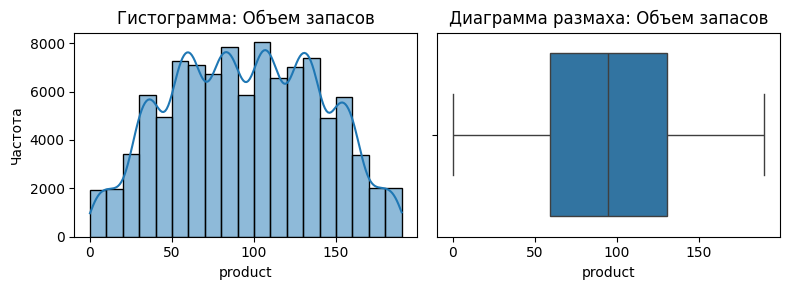


Статистика по Объем запасов:
Среднее: 95.0000 | Медиана: 94.9256
Минимум: 0.0000 | Максимум: 190.0298


In [26]:
plot_distribution(df2, 'product', title='Объем запасов', figsize=(8, 3))

В данных о третьем регионе все признаки имеют нормальное распределение с неольшим количеством выбросов. Распределение объема запасов схоже с первым регионом, но в среднем запасов **больше** 92.5 в первом против 95 в третьем регионе - потенциально самый прибильный регион.

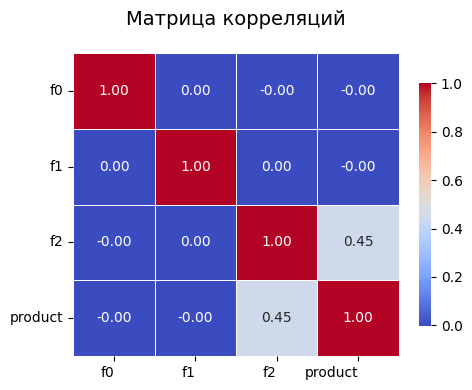

In [27]:
plot_matrix(df2, cols, 'Корреляция признаков', figsize=(5,4))

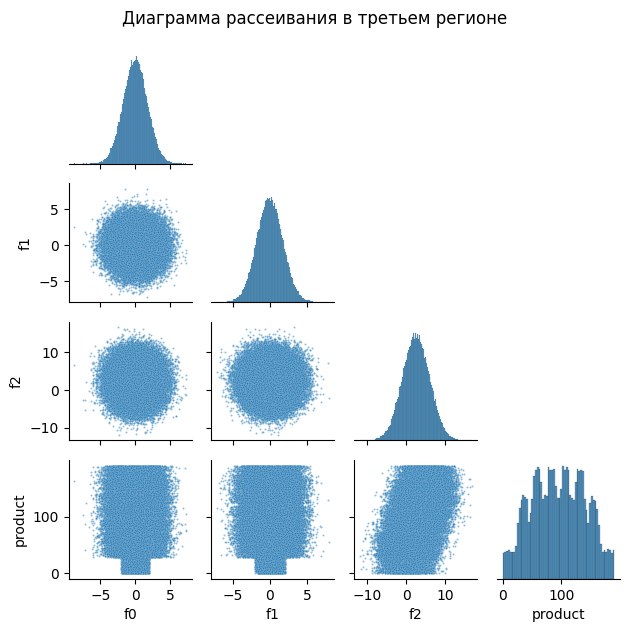

In [28]:
plot_pairplot(df2, title='Диаграмма рассеивания в третьем регионе')

f0, f1 имеют нулевую корреляцию с нулевым признаком, но на диаграмме видно, что узкий диапазон значений представляет минимальные объёмы запасов - стоит опробовать различные преобразования с этими признаками чтобы выделить это для модели, f2 как и в первом регионе имеет небольшую линейную связь с целевым признаком.

## Вывод <a id="end"></a>

Основные особенности после обзора и исследования данных:
* Данные о втором регионе (geo_data_1) имеют критические аномалии: целевой признак представлен лишь 12-ю значениями на 100 тысяч скважен, и идеально линейно зависим от признака f2, который также распределён лишь в 6 групп значений (тоже аномалия) - это позволяет полностью предсказать объём от f2. Обучать модель на таких данных бессмысленно. В остальных данных проблем нет;
* В первом регионе нам удалость найти и разделить 2 группы значений в данных, это поможет улучшить модель сделав предсказания точнее т.к. распределение объёма по этим группам разное. Средний запас объёма в скважинах равен 92.5;
* Третий регион содежит самый большой средний объём запасов в скважинах: 95 - это делает его потенциально самым прибыльным. Признаки объясняют целевой хуже чем в первом регионе, хотя есть предпосылки для развития: узкий диапазон значений f0 и f1 представляют лишь минимальные объёмы запасов, это позволит отделить самые убыточные скважены;

**Итого**: Самый оптимальный оптимальный кандиат для обучения первый регион (geo_data_0), так как удалось разработать новый признак по данным модель будет точнее, но самым лучшим по выручке может быть третий регион имея бОльшие запасы объёма, если удастся улучшить признаки и обучить модель.